# Diagnostic Breast Cancer Dataset

# Breast Cancer Diagnostic Classification with PyTorch

This notebook builds a simple feedforward neural network using PyTorch to classify 
breast cancer tumours as **malignant** or **benign** based on features extracted from 
digitised images of fine needle aspirate (FNA) biopsies.

## Dataset
The [Wisconsin Diagnostic Breast Cancer (WDBC)](https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset) 
dataset contains **569 samples** and **30 numerical features** describing characteristics 
of cell nuclei, such as radius, texture, perimeter, area, and smoothness — each recorded 
as mean, standard error, and worst value.

## Objective
Train a binary classifier to distinguish:
- `0` → Benign
- `1` → Malignant

## Approach
- Data preprocessing with `StandardScaler` (fit on train only)
- Simple `nn.Sequential` model with one hidden layer
- Training with `CrossEntropyLoss` and `Adam` optimiser
- Evaluation via loss/accuracy curves and a confusion matrix

In [163]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn  # nn contains all of PyTorch's building blocks for neural networks
import torch.optim as optim  # Import the entire optim module
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [165]:
# Check PyTorch version
print(f"PyTorch version: {torch.__version__}")
print(f"pandas version:{pd.__version__}")
print(f"numpy version:{np.__version__}")
print(f"matplotlib version:{plt.matplotlib.__version__}")

PyTorch version: 2.3.0
pandas version:2.2.2
numpy version:1.26.4
matplotlib version:3.9.2


# Load preprocessed data

In [168]:
path = Path(kagglehub.dataset_download("ahmeduzaki/diagnostic-breast-cancer-dataset"))

csv_path = path / "Diagnostic Breast Cancer Dataset.csv"

# Inspecting the data

In [171]:
df = pd.read_csv(csv_path)

df.head()

,ID,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Symmetry,...,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension,Diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Malignant
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Malignant
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Malignant
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Malignant
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Malignant


In [173]:
# Checking shape
df.shape

(569, 32)

In [175]:
# Check for missing values
df.isna().sum()

ID                         0
Mean Radius                0
Mean Texture               0
Mean Perimeter             0
Mean Area                  0
Mean Smoothness            0
Mean Compactness           0
Mean Concavity             0
Mean Concave Points        0
Mean Symmetry              0
Mean Fractal Dimension     0
Radius SE                  0
Texture SE                 0
Perimeter SE               0
Area SE                    0
Smoothness SE              0
Compactness SE             0
Concavity SE               0
Concave Points SE          0
Symmetry SE                0
Fractal Dimension SE       0
Worst Radius               0
Worst Texture              0
Worst Perimeter            0
Worst Area                 0
Worst Smoothness           0
Worst Compactness          0
Worst Concavity            0
Worst Concave Points       0
Worst Symmetry             0
Worst Fractal Dimension    0
Diagnosis                  0
dtype: int64

In [177]:
# Checking summary statistics
df.describe()

,ID,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Symmetry,...,Worst Radius,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [179]:
# Checking column names
df.columns

Index(['ID', 'Mean Radius', 'Mean Texture', 'Mean Perimeter', 'Mean Area',
       'Mean Smoothness', 'Mean Compactness', 'Mean Concavity',
       'Mean Concave Points', 'Mean Symmetry', 'Mean Fractal Dimension',
       'Radius SE', 'Texture SE', 'Perimeter SE', 'Area SE', 'Smoothness SE',
       'Compactness SE', 'Concavity SE', 'Concave Points SE', 'Symmetry SE',
       'Fractal Dimension SE', 'Worst Radius', 'Worst Texture',
       'Worst Perimeter', 'Worst Area', 'Worst Smoothness',
       'Worst Compactness', 'Worst Concavity', 'Worst Concave Points',
       'Worst Symmetry', 'Worst Fractal Dimension', 'Diagnosis'],
      dtype='object')

In [181]:
# Checking labels
df.Diagnosis.unique()

array(['Malignant', 'Benign'], dtype=object)

## Mapping the diagnosis (labels) for classification.

In [184]:
labels = df["Diagnosis"].map({"Benign": 0, "Malignant": 1})
labels

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: Diagnosis, Length: 569, dtype: int64

## Selecting features and sanity check

In [187]:
features = df.drop(["ID", "Diagnosis"], axis=1)
features

,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Symmetry,Mean Fractal Dimension,...,Worst Radius,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [189]:
# Sanity checks
X = torch.tensor(features.values, dtype=torch.float32)
y = torch.tensor(labels.values, dtype=torch.long)
X,y

(tensor([[1.7990e+01, 1.0380e+01, 1.2280e+02,  ..., 2.6540e-01, 4.6010e-01,
          1.1890e-01],
         [2.0570e+01, 1.7770e+01, 1.3290e+02,  ..., 1.8600e-01, 2.7500e-01,
          8.9020e-02],
         [1.9690e+01, 2.1250e+01, 1.3000e+02,  ..., 2.4300e-01, 3.6130e-01,
          8.7580e-02],
         ...,
         [1.6600e+01, 2.8080e+01, 1.0830e+02,  ..., 1.4180e-01, 2.2180e-01,
          7.8200e-02],
         [2.0600e+01, 2.9330e+01, 1.4010e+02,  ..., 2.6500e-01, 4.0870e-01,
          1.2400e-01],
         [7.7600e+00, 2.4540e+01, 4.7920e+01,  ..., 0.0000e+00, 2.8710e-01,
          7.0390e-02]]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
         0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
         1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
         0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 

In [191]:
print(f"X shape: {X.shape}")       # e.g. torch.Size([569, 30])
print(f"y shape: {y.shape}")       # e.g. torch.Size([569])
print(f"Classes: {y.unique()}")    # tensor([0, 1])

X shape: torch.Size([569, 30])
y shape: torch.Size([569])
Classes: tensor([0, 1])


# Data preparation and normalisation

In [198]:
# --- 1. Data prep ---

# Create a random seed
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    features.to_numpy(), labels.to_numpy(), test_size=0.2, random_state=SEED,
    stratify=labels.to_numpy()
)

# Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit only on train
X_test = scaler.transform(X_test)  # transform test with train stats

# Tensor conversion
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# Build a model

In [201]:
# --- 2. Model ---
class Classifier(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.model(x)

In [203]:
n_features = X_train.shape[1]
n_classes  = len(torch.unique(y_train))
model      = Classifier(n_features, n_classes)

# Loss and optimiser

In [206]:
# --- 3. Loss & optimiser ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training Loop

Epoch: 0 | Loss: 0.80969, Accuracy: 34.73% | Test loss: 0.79447, Test acc: 34.21%
Epoch: 10 | Loss: 0.57322, Accuracy: 80.22% | Test loss: 0.56129, Test acc: 78.07%
Epoch: 20 | Loss: 0.40516, Accuracy: 91.43% | Test loss: 0.39718, Test acc: 92.11%
Epoch: 30 | Loss: 0.29221, Accuracy: 93.41% | Test loss: 0.28921, Test acc: 94.74%
Epoch: 40 | Loss: 0.22047, Accuracy: 94.95% | Test loss: 0.22100, Test acc: 94.74%
Epoch: 50 | Loss: 0.17519, Accuracy: 95.60% | Test loss: 0.17787, Test acc: 94.74%
Epoch: 60 | Loss: 0.14565, Accuracy: 96.92% | Test loss: 0.14958, Test acc: 96.49%
Epoch: 70 | Loss: 0.12530, Accuracy: 97.36% | Test loss: 0.13024, Test acc: 97.37%
Epoch: 80 | Loss: 0.11048, Accuracy: 97.80% | Test loss: 0.11659, Test acc: 98.25%
Epoch: 90 | Loss: 0.09925, Accuracy: 98.02% | Test loss: 0.10665, Test acc: 98.25%


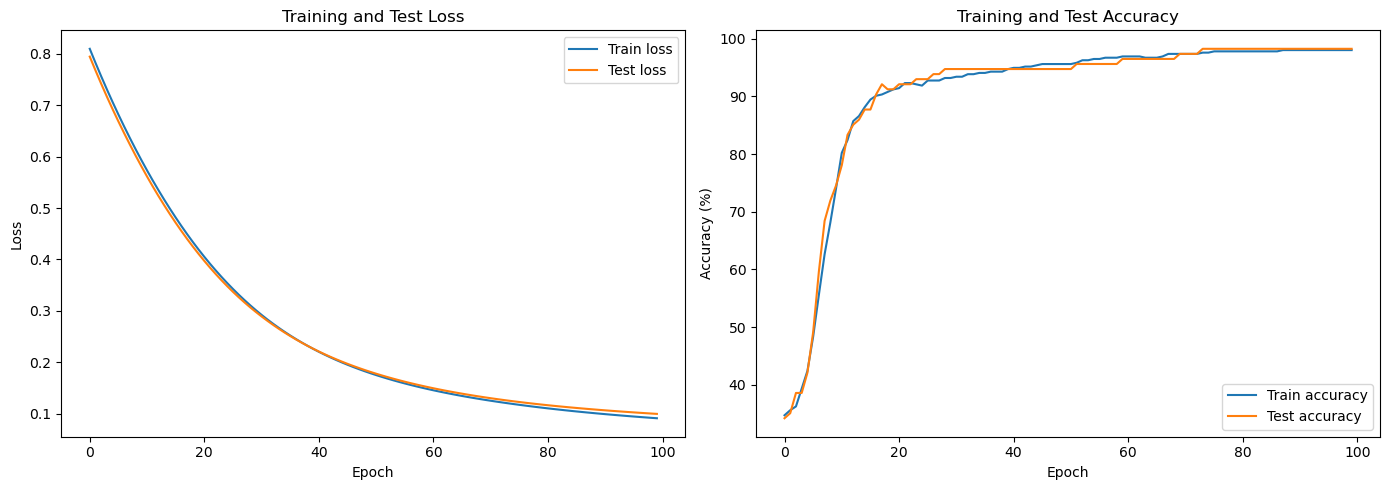

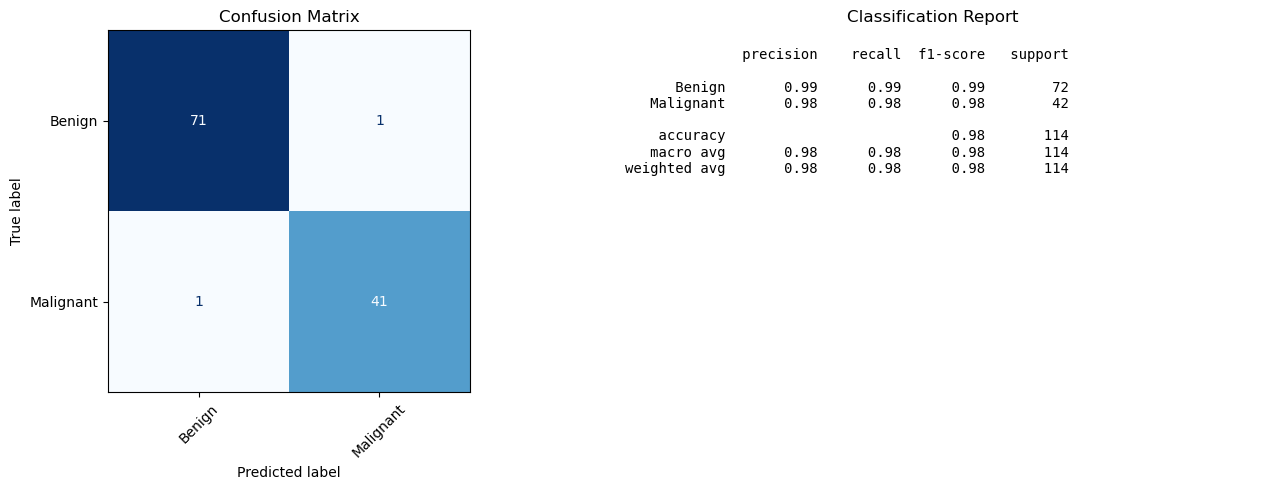

In [209]:
# --- 4. Training loop ---
# Initialise tracking lists
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

EPOCHS = 100

for epoch in range(EPOCHS):
    # Training
    model.train()
    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

    acc = (logits.argmax(dim=1) == y_train).float().mean() * 100

    # Evaluation
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = criterion(test_logits, y_test)
        test_acc = (test_logits.argmax(dim=1) == y_test).float().mean() * 100

    # Track
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    train_accuracies.append(acc.item())
    test_accuracies.append(test_acc.item())

    if epoch % 10 == 0:
        print(
            f"Epoch: {epoch} | "
            f"Loss: {loss:.5f}, Accuracy: {acc:.2f}% | "
            f"Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%"
        )

# Plotting
# --- Figure 1: Training curves ---
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

axes1[0].plot(train_losses, label="Train loss")
axes1[0].plot(test_losses, label="Test loss")
axes1[0].set_xlabel("Epoch")
axes1[0].set_ylabel("Loss")
axes1[0].set_title("Training and Test Loss")
axes1[0].legend()

axes1[1].plot(train_accuracies, label="Train accuracy")
axes1[1].plot(test_accuracies, label="Test accuracy")
axes1[1].set_xlabel("Epoch")
axes1[1].set_ylabel("Accuracy (%)")
axes1[1].set_title("Training and Test Accuracy")
axes1[1].legend()

plt.tight_layout()
plt.show()
print()

# --- Figure 2: Evaluation ---
model.eval()
with torch.inference_mode():
    preds = model(X_test).argmax(dim=1).numpy()
    true = y_test.numpy()

class_names = ["Benign", "Malignant"]

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(true, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, ax=axes2[0], colorbar=False)
axes2[0].set_title("Confusion Matrix")

report = classification_report(true, preds, target_names=class_names)
axes2[1].text(
    0.05, 0.95, report,
    transform=axes2[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    fontfamily="monospace"
)
axes2[1].set_title("Classification Report")
axes2[1].axis("off")

plt.tight_layout()
plt.show()
# print(report)

# Conclusion

This notebook demonstrates a compact PyTorch feedforward classifier for breast cancer
diagnosis using tabular morphological features extracted from FNA biopsy images.

The model achieved **98% accuracy** on the held-out test set (114 samples, stratified
split), with a **malignant recall of 0.98** -- meaning only one malignant case in 42
was missed. In a clinical screening context, recall on the malignant class is the
critical metric, as false negatives carry far greater consequence than false positives.

Precision and recall were balanced across both classes (benign: 0.99 / 0.99;
malignant: 0.98 / 0.98), with no meaningful trade-off between them at this operating
point.

**Potential next steps:**
- Compare against logistic regression and random forest baselines
- Add k-fold cross-validation for more robust performance estimates
- Tune the decision threshold to maximise malignant recall
- Add SHAP-based feature importance to identify the morphological drivers of malignancy